# Segmentasi Baris Tulisan Tangan (v2 - untuk foto resolusi tinggi)

Versi ini menggunakan **CLAHE** (normalisasi pencahayaan lokal) + **Otsu thresholding**, lebih cocok untuk foto kamera HP dengan bayangan/pencahayaan tidak merata dan resolusi besar (>1500px).

Untuk gambar resolusi kecil & bersih (seperti hasil scan), gunakan notebook versi pertama (`segmentasi_baris.ipynb`).

In [46]:
# ============================================================
# KONFIGURASI — edit bagian ini saja
# ============================================================
IMG_PATH   = "gambar_mentah/13.jpg"     # path gambar input
OUTPUT_DIR = "segmentation"  # folder output

# Parameter (biasanya tidak perlu diubah)
CROP_RIGHT_PCT = 0.96  # buang X% terakhir lebar gambar (untuk hilangkan kabel spiral/jilid)
MIN_INK     = 0.04     # sensitivitas deteksi baris
PADDING     = 2        # pixel ekstra atas-bawah tiap crop
MIN_CC      = 2        # min. jumlah huruf per baris
MIN_CC_AREA = 50        # min. ukuran huruf dalam pixel
PEAK_DISTANCE = 20      # jarak minimum antar baris (px) - naikkan untuk foto resolusi besar
# ============================================================

In [47]:
import os
import cv2
import numpy as np
from scipy.ndimage import uniform_filter1d
from scipy.signal import find_peaks, savgol_filter
import matplotlib.pyplot as plt

print('✅ Library siap')

✅ Library siap


✅ Gambar: 642x887 px -> setelah crop kanan: 616x887 px


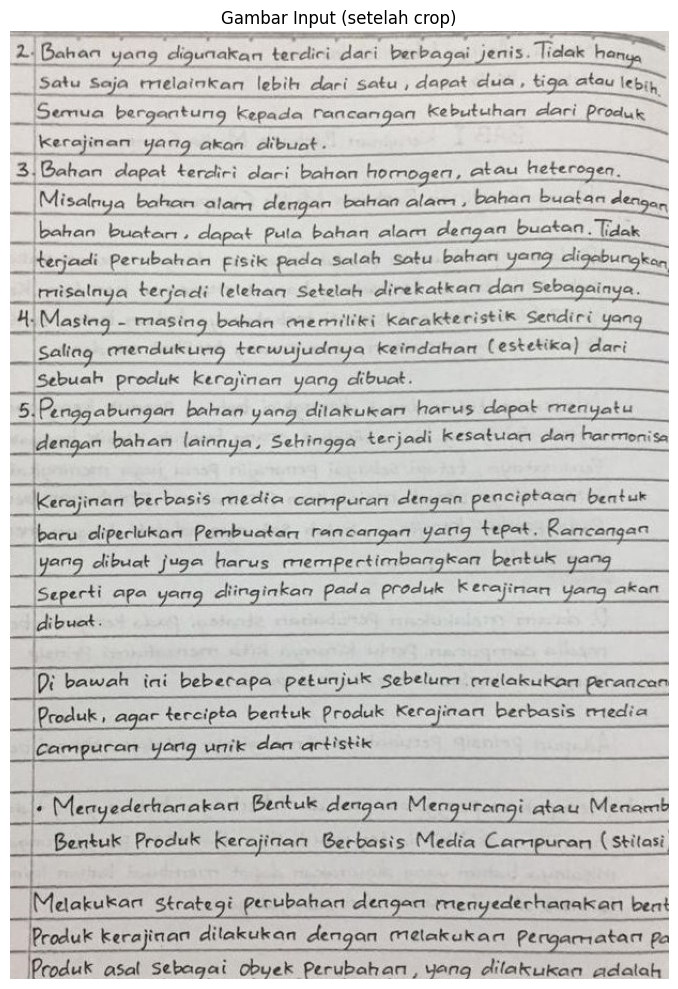

In [48]:
# ── Baca gambar & crop strip kanan ──────────────────────────
img_full = cv2.imread(IMG_PATH)
if img_full is None:
    raise FileNotFoundError(f"❌ File '{IMG_PATH}' tidak ditemukan!")

H0, W0 = img_full.shape[:2]
crop_right = int(W0 * CROP_RIGHT_PCT)
img = img_full[:, :crop_right, :]
H, W = img.shape[:2]
print(f'✅ Gambar: {W0}x{H0} px -> setelah crop kanan: {W}x{H} px')

plt.figure(figsize=(8, 10))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Gambar Input (setelah crop)')
plt.axis('off')
plt.tight_layout()
plt.show()

✅ Pre-processing selesai


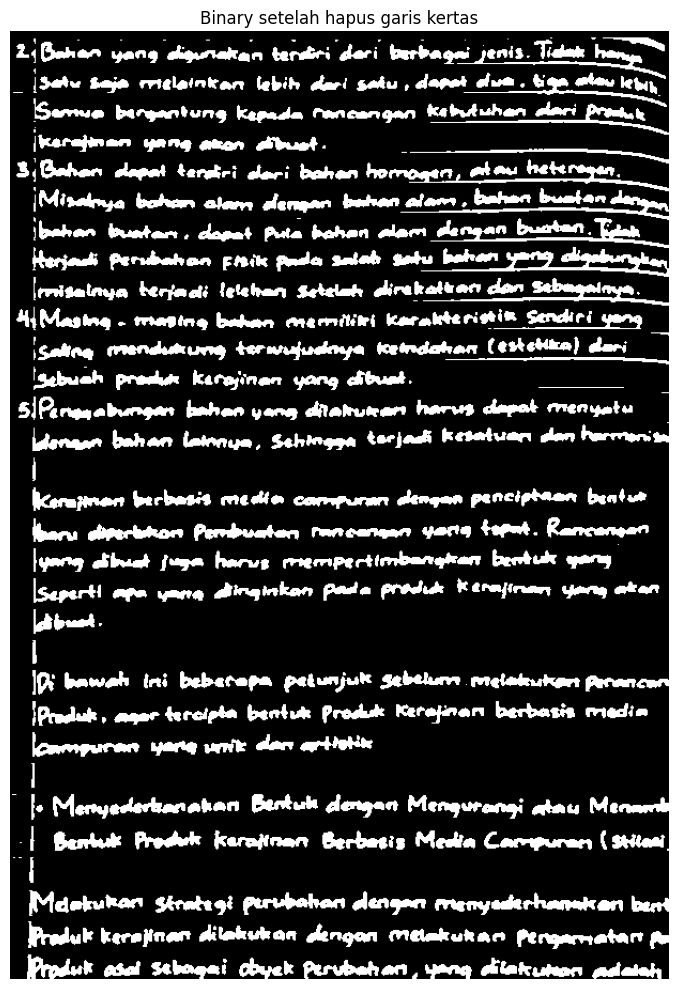

In [49]:
# ── Pre-processing: CLAHE + Otsu ────────────────────────────
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# CLAHE: normalisasi kontras lokal -> mengatasi bayangan
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(16, 16))
gray_clahe = clahe.apply(gray)

blurred = cv2.GaussianBlur(gray_clahe, (5, 5), 0)
_, binary = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Hapus garis horizontal kertas bergaris
kernel_pre_v    = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 3))
binary_pre      = cv2.dilate(binary, kernel_pre_v, iterations=1)
kernel_line     = cv2.getStructuringElement(cv2.MORPH_RECT, (int(W * 0.5), 1))
horiz_lines     = cv2.morphologyEx(binary_pre, cv2.MORPH_OPEN, kernel_line, iterations=1)
kernel_dilate_f = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
horiz_lines_d   = cv2.dilate(horiz_lines, kernel_dilate_f, iterations=1)
binary_clean    = cv2.subtract(binary, horiz_lines_d)

print('✅ Pre-processing selesai')

plt.figure(figsize=(8, 10))
plt.imshow(binary_clean, cmap='gray')
plt.title('Binary setelah hapus garis kertas')
plt.axis('off')
plt.tight_layout()
plt.show()

📏 Estimasi tinggi baris: 29px | Puncak terdeteksi: 27


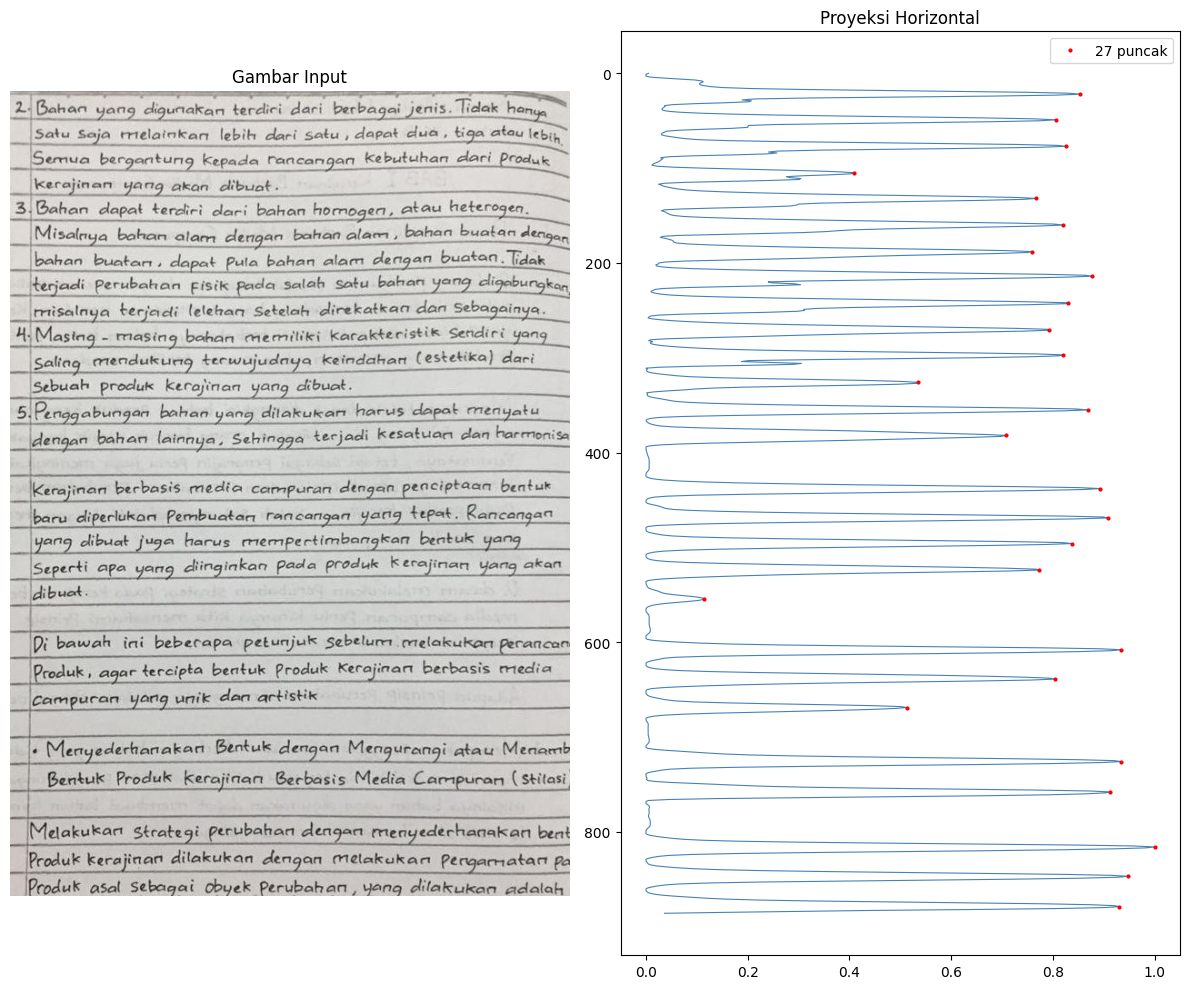

In [50]:
# ── Proyeksi horizontal + deteksi puncak baris ────────────
row_sums   = np.sum(binary_clean, axis=1) / 255.0
row_smooth = uniform_filter1d(row_sums.astype(float), size=3)
row_savgol = savgol_filter(row_smooth, window_length=7, polyorder=2)
row_savgol = np.clip(row_savgol, 0, None)
row_norm   = row_savgol / row_savgol.max()

peaks, _ = find_peaks(row_norm, height=MIN_INK, distance=PEAK_DISTANCE, prominence=MIN_INK)
lh = int(np.median(np.diff(peaks))) if len(peaks) >= 2 else 20
print(f'📏 Estimasi tinggi baris: {lh}px | Puncak terdeteksi: {len(peaks)}')

fig, axes = plt.subplots(1, 2, figsize=(12, 10))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Gambar Input'); axes[0].axis('off')
axes[1].plot(row_norm, range(len(row_norm)), linewidth=0.8, color='steelblue')
axes[1].plot(row_norm[peaks], peaks, 'r.', markersize=4, label=f'{len(peaks)} puncak')
axes[1].invert_yaxis()
axes[1].set_title('Proyeksi Horizontal')
axes[1].legend()
plt.tight_layout()
plt.show()

In [51]:
# ── Segmentasi & filter ────────────────────────────────────
separators = [0]
for i in range(len(peaks) - 1):
    seg        = row_norm[peaks[i]: peaks[i + 1]]
    valley_abs = peaks[i] + int(np.argmin(seg))
    separators.append(valley_abs)
separators.append(H - 1)

segments = []
for i in range(len(separators) - 1):
    y1, y2  = separators[i], separators[i + 1]
    seg_ink = row_sums[y1: y2 + 1]
    nonzero = np.where(seg_ink > 2)[0]
    if len(nonzero) == 0:
        continue
    # Clamp ke batas separator agar tidak overlap dengan tetangga
    ty1 = max(y1, y1 + nonzero[0]  - PADDING)
    ty2 = min(y2, y1 + nonzero[-1] + PADDING)
    if (ty2 - ty1) < 10:
        continue
    # Filter connected component
    crop_bin = binary_clean[ty1: ty2 + 1, :]
    num_labels, _, stats, _ = cv2.connectedComponentsWithStats(crop_bin, connectivity=8)
    big_cc = sum(1 for j in range(1, num_labels) if stats[j, cv2.CC_STAT_AREA] >= MIN_CC_AREA)
    if big_cc >= MIN_CC:
        segments.append((ty1, ty2))

print(f'✅ {len(segments)} baris terdeteksi')

✅ 27 baris terdeteksi


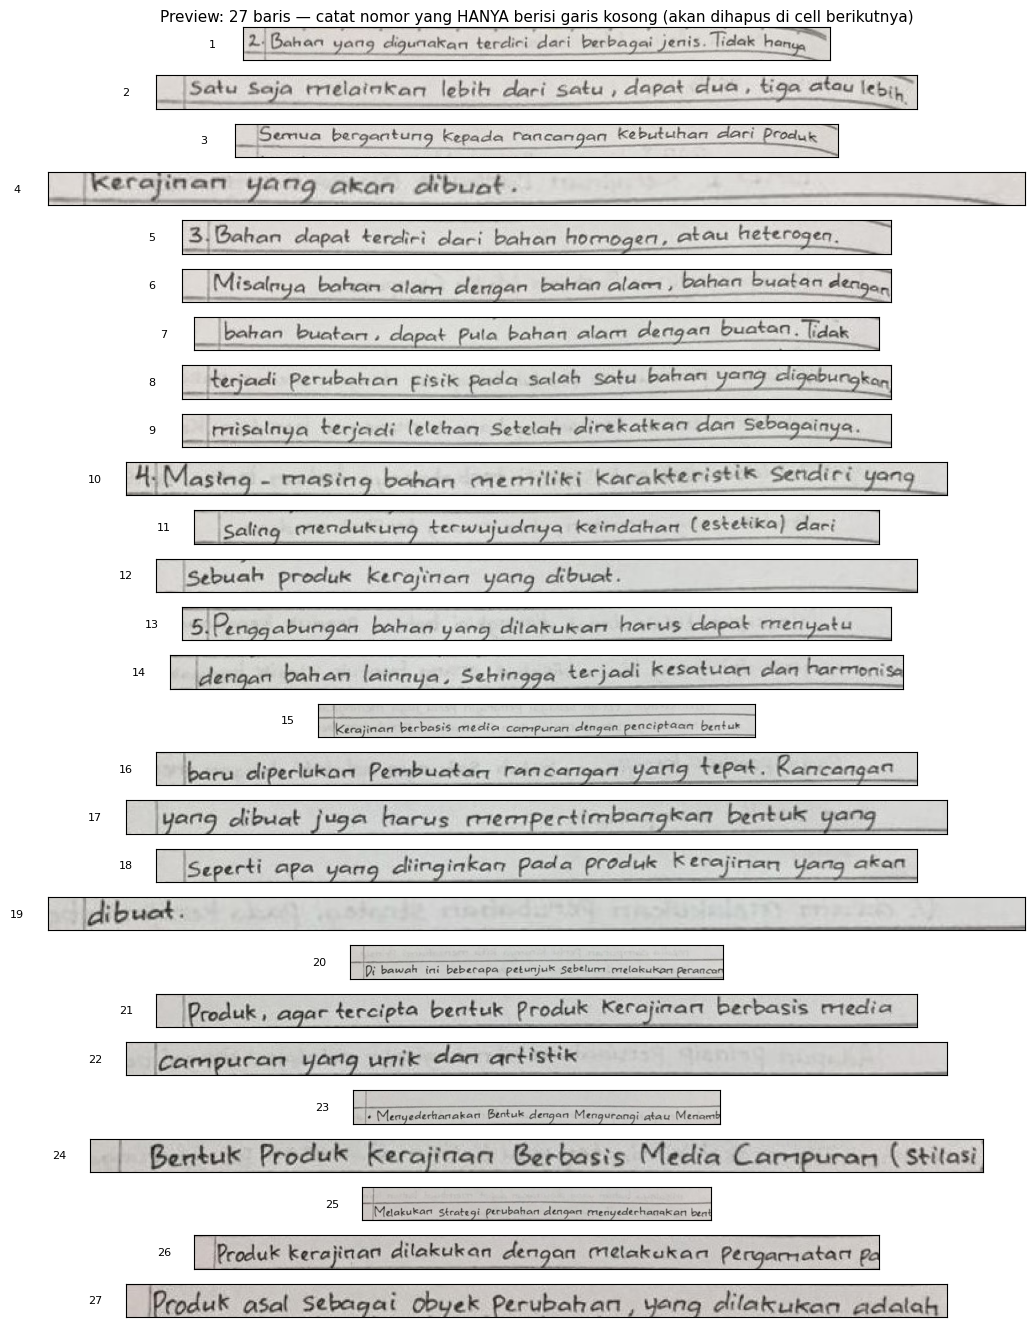

In [52]:
# ── Preview semua hasil crop (dengan nomor) ────────────────
n = len(segments)
fig, axes = plt.subplots(n, 1, figsize=(14, n * 0.5))
if n == 1: axes = [axes]

for i, (ax, (y1, y2)) in enumerate(zip(axes, segments)):
    crop = img[y1: y2+1, :, :]
    ax.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
    ax.set_ylabel(f'{i+1}', fontsize=8, rotation=0, labelpad=22, va='center')
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle(f'Preview: {n} baris — catat nomor yang HANYA berisi garis kosong (akan dihapus di cell berikutnya)', fontsize=11)
plt.tight_layout()
plt.show()

In [53]:
# ── [OPSIONAL] Buang baris yang salah (hanya garis kosong) ──
# Lihat preview di atas, lalu isi nomor baris yang ingin DIBUANG.
# Nomor sesuai label di preview (mulai dari 1).
#
# Contoh: BUANG_NOMOR = [1, 3, 5, 6, 12, 16, 23, 24]

BUANG_NOMOR = []   # ← edit di sini, kosongkan [] jika tidak ada yang perlu dibuang

segments_final = [seg for i, seg in enumerate(segments) if (i+1) not in BUANG_NOMOR]
print(f'✅ Setelah filter manual: {len(segments_final)} baris (dari {len(segments)})')

✅ Setelah filter manual: 27 baris (dari 27)


In [54]:
# ── Simpan semua crop ──────────────────────────────────────
os.makedirs(OUTPUT_DIR, exist_ok=True)

for idx, (y1, y2) in enumerate(segments_final):
    crop     = img[y1: y2+1, :, :]
    filename = os.path.join(OUTPUT_DIR, f'{idx+1:03d}.png')
    cv2.imwrite(filename, crop)

print(f'🎉 Selesai! {len(segments_final)} baris disimpan ke folder "{OUTPUT_DIR}/"')

🎉 Selesai! 27 baris disimpan ke folder "segmentation/"
